<a href="https://colab.research.google.com/github/Oscardobanks/machine_learning_practice/blob/main/Multivariable_Linear_Regression_with_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Multivariable Linear Regression with Gradient Descent**
This notebook demonstrates linear regression of multiple variables using gradient descent. It starts with a simple implementation of a single variable linear regression and then proceeds to extend the method to multiple variables in a way that allows intuitive understanding of the process

In [2]:
import kagglehub as kh
import pandas as pd
from pathlib import Path

In [3]:
path = kh.dataset_download("hussainnasirkhan/multiple-linear-regression-dataset")
df = pd.read_csv(Path(path) / "multiple_linear_regression_dataset.csv")

100%|██████████| 367/367 [00:00<00:00, 399kB/s]

Extracting files...


In [4]:
df

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
X1 = np.array(df.age)
X2 = np.array(df.experience)
Y = np.array(df.income)

X1, X2, Y

(array([25, 30, 47, 32, 43, 51, 28, 33, 37, 39, 29, 47, 54, 51, 44, 41, 58,
        23, 44, 37]),
 array([ 1,  3,  2,  5, 10,  7,  5,  4,  5,  8,  1,  9,  5,  4, 12,  6, 17,
         1,  9, 10]),
 array([30450, 35670, 31580, 40130, 47830, 41630, 41340, 37650, 40250,
        45150, 27840, 46110, 36720, 34800, 51300, 38900, 63600, 30870,
        44190, 48700]))

In [138]:
m1, m2, c = 5, 5, 10
alpha = 0.0004
epochs = 500
costs = []

In [139]:
# This is the part where we iterate multiple times to adjust the parameters
# and train the model
for j in range(epochs):
  Y_pred = m1 * X1 + m2 * X2 + c
  error = Y - Y_pred
  cost = np.mean(error**2)
  costs.append(cost)
  dm1 = -2 * np.mean(X1 * error)
  dm2 = -2 * np.mean(X2 * error)
  dc = -2 * np.mean(error)

  m1 = m1 - alpha * dm1
  m2 = m2 - alpha * dm2
  c = c - alpha * dc

print("gradients", dm1, dm2, dc)
print("updates", -alpha * dm1, -alpha * dm2, -alpha * c)
print("parameters", m1, m2, c)
print("cost", cost)

gradients 154.31939701507218 -477.3404223689242 -3222.061988784841
updates -0.061727758806028876 0.19093616894756968 -0.2611820810982715
parameters 732.2437466811763 1522.2700597354183 652.9552027456788
cost 51064315.41050881


### **Visualization of prediction**
The best way to visualize and compare the prediction vs the actual is to plot `Y` vs itself in a line plot and then `Y` vs `Y_pred` in a scatter plot. That allows easy view of the performance of the model in prediction.

In [140]:
Y, Y_pred, Y.shape, Y_pred.shape

(array([30450, 35670, 31580, 40130, 47830, 41630, 41340, 37650, 40250,
        45150, 27840, 46110, 36720, 34800, 51300, 38900, 63600, 30870,
        44190, 48700]),
 array([20481.38236252, 27187.06798185, 38114.18192376, 31695.83717786,
        47361.59301453, 48653.79943935, 28766.6152801 , 30906.06352874,
        35357.36455006, 41388.21286964, 23410.60426028, 48768.73578873,
        47806.55761554, 44087.56206866, 51138.05673611, 39808.66557139,
        69000.7289961 , 19016.77141364, 46571.81936541, 42967.76016789]),
 (20,),
 (20,))

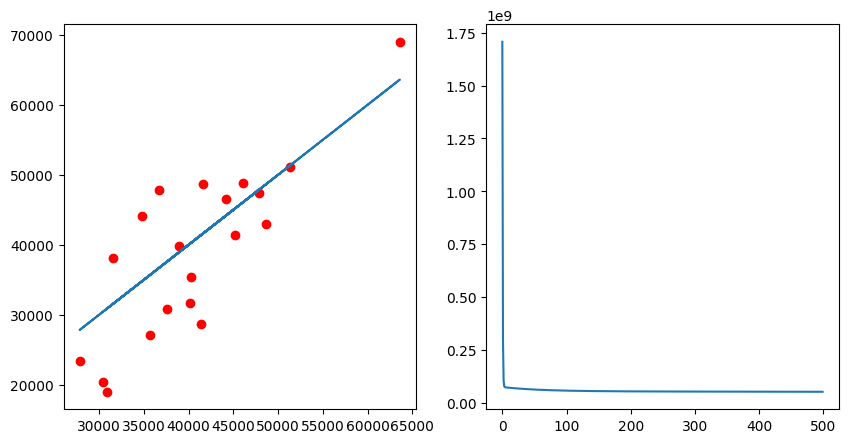

In [141]:
# Plot to compare prediction vs. actual
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(Y, Y)
plt.scatter(Y, Y_pred, color='r')

# Plot of loss over epochs.
plt.subplot(1,2,2)
plt.plot(costs)